# Linger Workflow
Below is the file structure. We start with fresh `LINGER_output/` and `data/` folders.
```
.
├── LINGER_data/
│   └── data_bulk/
│
├── LINGER_output/
│   ├── cell_population_TF_RE_binding.txt
│   ├── cell_population_cis_regulatory.txt
│   ├── cell_population_trans_regulatory.txt
│   └── ...
│
└── data/
    ├── Peaks.txt
    ├── TG_pseudobulk.tsv
    ├── RE_pseudobulk.tsv
    ├── adata_RNA.h5ad
    └── adata_ATAC.h5ad
```

In [1]:
rm -rf LINGER_output/*

In [2]:
rm -rf data/*

## 1. Get the input data
- `.h5` matrix with both RNA and ATAC
- cell type annotation

In [3]:
%%bash
wget --progress=bar:force -O data/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5 https://cf.10xgenomics.com/samples/cell-arc/1.0.0/pbmc_granulocyte_sorted_10k/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5
wget --progress=bar:force -O data --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=17PXkQJr8fk0h90dCkTi3RGPmFNtDqHO_' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=17PXkQJr8fk0h90dCkTi3RGPmFNtDqHO_" -O data/PBMC_label.txt && rm -rf /tmp/cookies.txt

--2026-03-10 13:14:41--  https://cf.10xgenomics.com/samples/cell-arc/1.0.0/pbmc_granulocyte_sorted_10k/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 162282142 (155M) [binary/octet-stream]
Saving to: 'data/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5'

data/pbmc_granulocy 100%[===================>] 154.76M   207MB/s    in 0.7s    

2026-03-10 13:14:43 (207 MB/s) - 'data/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5' saved [162282142/162282142]

--2026-03-10 13:14:44--  https://docs.google.com/uc?export=download&confirm=&id=17PXkQJr8fk0h90dCkTi3RGPmFNtDqHO_
Resolving docs.google.com (docs.google.com)... 142.250.110.113, 142.250.110.100, 142.250.110.138, ...
Connecting to docs.google.com (docs.google.com)|142.2

In [4]:
ls data

PBMC_label.txt  pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5


In [ ]:
import scanpy as sc
adata = sc.read_10x_h5('data/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5', gex_only=False)

In [ ]:
import scipy.sparse as sp
import pandas as pd
matrix=adata.X.T
adata.var['gene_ids']=adata.var.index
features=pd.DataFrame(adata.var['gene_ids'].values.tolist(),columns=[1])
features[2]=adata.var['feature_types'].values
barcodes=pd.DataFrame(adata.obs_names,columns=[0])
label = pd.read_csv('data/PBMC_label.txt',sep='\t',header=0)
from LingerGRN.preprocess import *
adata_RNA,adata_ATAC=get_adata(matrix,features,barcodes,label)# adata_RNA and adata_ATAC are scRNA and scATAC

In [7]:
adata_RNA

View of AnnData object with n_obs × n_vars = 9543 × 36601
    obs: 'barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [8]:
adata_ATAC

View of AnnData object with n_obs × n_vars = 9543 × 108377
    obs: 'barcode', 'sample', 'label'
    var: 'gene_ids'

## 2. Filter cells and genes

In [ ]:
sc.pp.filter_cells(adata_RNA, min_genes=200)
sc.pp.filter_genes(adata_RNA, min_cells=3)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
sc.pp.filter_genes(adata_ATAC, min_cells=3)

selected_barcode = list(set(adata_RNA.obs['barcode'].values) & set(adata_ATAC.obs['barcode'].values))

barcode_idx = pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]

barcode_idx = pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]

## 3 Pseudo-bulk (`pseudo_bulk.py`)
This function creates *metacells* : aggregated pseudo-cells that represent local neighborhoods in the data. 

In [ ]:
# Generate pseudo-bulk/metacell
import os
from LingerGRN.pseudo_bulk import *

samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]

TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])

n_samples = adata_RNA.obs['sample'].nunique()
singlepseudobulk = (n_samples > 10)

for tempsample in samplelist:

    # get cells from only tempsample
    adata_RNAtemp = adata_RNA[adata_RNA.obs['sample' ] == tempsample]
    adata_ATACtemp = adata_ATAC[adata_ATAC.obs['sample'] == tempsample]

    TG_pseudobulk_temp, RE_pseudobulk_temp = pseudo_bulk(adata_RNAtemp, adata_ATACtemp, singlepseudobulk)  
    
    TG_pseudobulk = pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk = pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    
    RE_pseudobulk[RE_pseudobulk > 100] = 100

In [ ]:
if not os.path.exists('data/'):
    os.mkdir('data/')
    
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')

In [12]:
ls data

PBMC_label.txt     adata_ATAC.h5ad
Peaks.txt          adata_RNA.h5ad
RE_pseudobulk.tsv  pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5
TG_pseudobulk.tsv


## 4. Preprocess

In [13]:
import os
from LingerGRN.preprocess import *
source = "/globalsc/ucl/inma/vangysel/Linger/"
GRNdir =  source + "LINGER_data/data_bulk/"
genome = 'hg38'
outdir = source + "LINGER_output/" 

In [14]:
method = 'LINGER'  

In [15]:
!df -h /tmp

Filesystem      Size  Used Avail Use% Mounted on
/dev/nvme0n1p1   32G  262M   32G   1% /tmp


In [16]:
from preprocess_fast import *
preprocess(TG_pseudobulk, RE_pseudobulk, GRNdir, genome, method, outdir)

Overlapping regions...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    3.4s
[Parallel(n_jobs=8)]: Done  11 out of  23 | elapsed:    4.3s remaining:    4.7s
[Parallel(n_jobs=8)]: Done  14 out of  23 | elapsed:    4.6s remaining:    2.9s
[Parallel(n_jobs=8)]: Done  17 out of  23 | elapsed:    4.9s remaining:    1.7s
[Parallel(n_jobs=8)]: Done  20 out of  23 | elapsed:    5.2s remaining:    0.8s
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed:    6.5s finished


Mapping gene expression...
Generate TF expression...
Generate RE chromatin accessibility...
Generate TF binding...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
/opt/conda/envs/env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   38.1s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   49.3s
/opt/conda/envs/env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[Parallel(n_jobs=4)]: Done  19 out of  23 | elapsed:  1.3min 

Generate Index...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 14907/14907 [00:43<00:00, 344.94it/s]


### About the preprocess function

1) `extract_overlap_regions` : overlap our peaks with the reference peaks
2) `gene_expression` : filters `TG_pseudobulk` to genes present in `bulk_gene_all.txt`, applies log2(1+x) and writes :
   - Exp.txt — log2 normalized expression matrix
   - Symbol.txt — gene names
   - Col.txt — metacell column names
<br><br>
3) `TF_expression` : subsets `Exp.txt` to TF genes only, writes:
    - TFexp.txt — TF expression matrix
    - TFName.txt — TF names
<br><br>
4) `RE_pseudobulk → Openness.txt` : peaks are written in the file without transformation
<br><br>
6) `load_TFbinding`: reads `MotifTarget_Matrix_{chr}.txt` (max. 2.8GB) and `MotifTarget_hg19_hg38_{chr}.txt` for all chromosomes, maps motif binding scores to your peaks, normalizes by motif weight, aggregates motifs to TFs via Match2.txt, writes:
    - TF_binding.txt (750MB) — peaks × TFs motif binding matrix where each value represents how strongly each TF's motif is present at each peak
<br><br>
7) `index_generate` loop : for each gene in `Symbol.txt`, records which RE indices and TF indices are relevant for that gene's neural network input (which TFs and which REs to use as input features for that gene) writes:
    - index.txt — per-gene mapping of RE and TF indices

```
extract_overlap_regions
  → Region.bed
  → match_hg19_peak.bed
  → hg19_Peak_hg19_gene_u.txt
  → MotifTarget_hg19_hg38_{chr}.txt  (×23)
  → Region_overlap_{chr}.bed         (×23)

gene_expression
  → Exp.txt
  → Symbol.txt
  → Col.txt

TF_expression
  → TFexp.txt
  → TFName.txt

directly
  → Openness.txt

load_TFbinding
  → TF_binding.txt

index_generate
  → index.txt

```

In [83]:
import pandas as pd
import torch

outdir  = 'LINGER_output/'
GRNdir  = 'LINGER_data/data_bulk/'

# --- preprocess outputs ---
Exp        = pd.read_csv(outdir + 'Exp.txt',         sep='\t', header=None)
Symbol     = pd.read_csv(outdir + 'Symbol.txt',      sep='\t', header=None)
Col        = pd.read_csv(outdir + 'Col.txt',         sep='\t', header=None)
TFexp      = pd.read_csv(outdir + 'TFexp.txt',       sep='\t', header=None)
TFName     = pd.read_csv(outdir + 'TFName.txt',      sep='\t', header=None)
Openness   = pd.read_csv(outdir + 'Openness.txt',    sep='\t', header=None)
TF_binding = pd.read_csv(outdir + 'TF_binding.txt',  sep='\t', header=None)
index      = pd.read_csv(outdir + 'index.txt',       sep='\t', header=None)
Region     = pd.read_csv(outdir + 'Region.bed',      sep='\t', header=None)
Region_overlap_chr1 = pd.read_csv(outdir + 'Region_overlap_chr1.bed', sep='\t', header=None)
hg19_Peak  = pd.read_csv(outdir + 'hg19_Peak_hg19_gene_u.txt', sep='\t', header=None)
MotifTarget_chr1 = pd.read_csv(outdir + 'MotifTarget_hg19_hg38_chr1.txt', sep='\t', header=None)
match_hg19 = pd.read_csv(outdir + 'match_hg19_peak.bed', sep='\t', header=None)
print()

In [ ]:
ls LINGER_output

## 5. Training


For each gene, LINGER trains a small neural network that predicts that gene's expression across metacells from its neighboring TFs and nearby peaks. The bulk atlas provides a starting point via pretrained weights and Fisher information, and the network is fine-tuned on your pseudobulk data.

### 5.1 Load_data
Loads everything preprocess produced plus bulk atlas indices. Creates :
- `data_merge.txt` : merge of Symbol.txt with gene_all, creates a table that maps each of your genes to its bulk atlas index and chromosome. This is how LINGER knows which pretrained bulk model corresponds to each gene in your dataset.
- `TF_match` : a mapping between your TF indices and bulk TF indices, needed to slice the right columns from the pretrained weight matrix.

``` 
outdir/Exp.txt          → Target  (genes × metacells, what the network predicts)
outdir/TFexp.txt        → Exp     (TFs × metacells, TF input features)
outdir/Openness.txt     → Opn     (peaks × metacells, RE input features)
outdir/TF_binding.txt   → adj_matrix_all  (peaks × TFs, motif binding — graph regularizer)
outdir/index.txt        → idx     (per-gene RE/TF indices)
GRNdir/{chr}_gene.txt   → gene_all  (bulk gene list with bulk indices)
GRNdir/{chr}_index.txt  → idx_bulk  (bulk per-gene TF/RE indices)
GRNdir/TFName.txt       → TFName_b  (bulk TF names)
outdir/TFName.txt       → TFName_s  (your TF names)
```

### 5.2 Chromosome loop

For each of the 23 chr, locate the genes on chr and load its bulk fisher information and bulk pre-trained weights (in `GRNdir`).

Then `sc_nn` is called for each chr. 

- `all_models_{chr}.pt` contains one pretrained network per gene in the bulk atlas. 

- `fisher_{chr}.pt` contains the Fisher information matrix for each bulk network — a measure of which weights were most important for the bulk task, used to prevent catastrophic forgetting.

### 5.3 `sc_nn` : per gene network training

Get inputs for NN of gene `ii` :

```python
TFtemp = Exp[TFidxtemp, :]               # expression of relevant TFs across metacells
REtemp = Opn[REidxtemp, :]               # accessibility of nearby peaks across metacells
inputs = np.vstack((TFtemp, REtemp))     # stack → (TFs+REs) × metacells
```

Also builds the **Graph Laplacian regularizer** that encodes the motif binding structure as a graph — TFs connected to the peaks they bind. Used in the loss to encourage the network to respect known TF-RE binding relationships <br>

Train for 100 epoch with loss being :

```python
loss = mse_loss(y_pred, y_tr)           # fit your pseudobulk expression
    + l1_norm * l1_lambda               # L1 regularization (sparsity)
    + l2_bulk                           # pull weights toward bulk pretrained values
    + lap_reg                           # respect TF-RE graph structure
```

### 5.4 After training
SHAP values are computed for every input feature (TFs and REs) across all metacells. These quantify how much each TF and each RE contributed to predicting this gene's expression — they become the regulatory scores used by `cis_reg` (RE-TG) and `trans_reg` (TF-TG) later.

```python
background = X_tr[np.random.choice(X_tr.shape[0], 50, replace=False)]
explainer = shap.DeepExplainer(net,background)
shap_values = explainer.shap_values(X_tr)
```

- net_{chr}.pt    — trained networks, one per gene (used by TF_RE_binding in LINGER mode)
- shap_{chr}.pt   — SHAP values, one per gene    (used by cis_reg and trans_reg)
- result_{chr}.txt — training scores per gene
- Loss_{chr}.txt  — loss curves per gene

### 5.6 Compelete training call stack
```
training(method='LINGER')
  ├── load_data()
  │     ← Exp.txt, TFexp.txt, Openness.txt, TF_binding.txt
  │     ← index.txt, Symbol.txt
  │     ← GRNdir/{chr}_gene.txt, {chr}_index.txt, {chr}_index_all.txt
  │     ← GRNdir/TFName.txt
  │     → data_merge.txt
  └── for each chr:
        ├── load fisher_{chr}.pt, all_models_{chr}.pt  (bulk prior)
        └── for each gene on this chr:
              sc_nn(...)
                ├── slice TF + RE inputs from Exp.txt + Openness.txt
                ├── build graph Laplacian from TF_binding.txt
                ├── align with bulk model weights via TF_match
                ├── train 100 epochs with MSE + L1 + EWC + Laplacian loss
                └── compute SHAP values
              → net_{chr}.pt
              → shap_{chr}.pt
              → result_{chr}.txt
              → Loss_{chr}.txt
```

In [18]:
outdir  = 'LINGER_output/'
GRNdir  = 'LINGER_data/data_bulk/'

In [20]:
from LINGER_tr_fast import *
training(GRNdir,'LINGER',outdir,'ReLU','Human')

With 8 CPUs, 64.00 GB RAM (avail. : 47.52 GB), start 8 workers


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
chr11:  98%|█████████▊| 852/873 [16:35<00:24,  1.17s/it]]A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr20:  54%|█████▍    | 218/403 [04:04<03:31,  1.14s/it]][Parallel(n_jobs=8)]: Done  17 out of  23 | elapsed: 28.9min remaining: 10.2min
Implicitly cleaning up <TemporaryDirectory '/localsc/vangysel/674126/tmp_xcz78gv'>
chr19: 100%|██████████| 1149/1149 [24:13<00:00,  1.27s/it]
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed: 47.7min finished
Implicitly cleaning up <TemporaryDirectory '/localsc/vangysel/674126/tmpb36uriox'>


## 6. Cell population GRN

### 6.1 TF-RE

`TF_RE_binding` calls `TF_RE_LINGER_chr`for each chromosome.

It extracts the first layer weights of the trained network — this is a matrix of shape (64, n_inputs) where n_inputs = n_TFs + n_REs for this gene. The first n_TFs columns correspond to TF inputs, the remaining n_RE columns correspond to RE inputs.

This gives a score for each TF-RE pair — how similarly the network weighted them in its first layer. High cosine similarity means the network learned that this TF and this RE jointly contribute to predicting the gene's expression, implying the TF binds at that RE.

- `chr{N}_cell_population_TF_RE_binding.txt` : per chr TF-RE binding matrix
- `cell_population_TF_RE_binding.txt  (peaks × TFs)` : concat all chr

In [22]:
import LL_net_fast as LL_net
LL_net.TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)

Generating cellular population TF binding strength ...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
chr19: 100%|██████████| 22/22 [04:31<00:00, 12.33s/it]
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed:  7.3min finished


In [23]:
re_tf = pd.read_csv("LINGER_output/cell_population_TF_RE_binding.txt", sep="\t")
re_tf.shape

(96533, 452)

In [24]:
re_tf.head(2)

,Unnamed: 0,FOXO1,ATF6,PKNOX2,GLIS3,PRDM9,ARNTL,KLF11,PAX7,HOXA5,...,ETV6,ESR2,MEF2A,IRF6,LEF1,HDX,KLF3,NFATC4,CENPB,EBF1
0,chr1:100028489-100029404,0.996001,0.993402,0.996922,0.717170,0.999455,0.995976,0.997356,0.998538,0.998437,...,0.997622,0.996915,0.997298,0.997229,0.997902,0.998779,0.997694,0.998453,0.942091,0.994827
1,chr1:100034436-100035279,0.994504,0.994990,0.997751,0.450822,0.998403,0.995997,0.997572,0.998020,0.997882,...,0.998078,0.998082,0.995481,0.997633,0.997179,0.998865,0.996100,0.997239,0.616690,0.995425


### 6.2 RE-TG

`cis_reg` calls `cis_shap` for each chromosome, basically recovers shap values for all (valid) genes on that chr.

The SHAP values have shape `metacells × (n_TFs + n_REs)` — one value per input feature per metacell. Taking the mean absolute value across metacells gives one importance score per input feature. Then only the RE portion is kept — the last `n_RE` columns — giving one score per nearby peak for how much it contributed to predicting this gene's expression.

These RE importance scores directly become the cis-regulatory scores — no multiplication with distance decay or prior scores as in baseline.


In [26]:
import LL_net_fast as LL_net
LL_net.cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)

chr10: 100%|██████████| 562/562 [00:00<00:00, 1070.62it/s]
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr15:   0%|          | 0/464 [00:00<?, ?it/s]A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr19: 100%|██████████| 1149/1149 [00:00<00:00, 1793.40it/s]


In [27]:
re_tg = pd.read_csv("LINGER_output/cell_population_cis_regulatory.txt", sep="\t")
re_tg.shape

(1529212, 3)

In [28]:
re_tg.head(2)

,chr1:100028489-100029404,AGL,0.00013112836684889102
0,chr1:100028489-100029404,CDC14A,0.000827
1,chr1:100028489-100029404,DBT,0.000067


### 6.3 TF-TG
`trans_reg` calls `trans_shap` for each chromosome, basically recovers shap values for all (valid) genes on that chr.

Same SHAP values as 6.2, same mean absolute operation, just the opposite slice — the first `n_TF` columns instead of the last `n_RE` columns.


In [30]:
import LL_net_fast as LL_net
LL_net.trans_reg(GRNdir,method,outdir,genome)

Generate trans-regulatory netowrk ...


chr4: 100%|██████████| 565/565 [00:00<00:00, 2083.32it/s]
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr2: 100%|██████████| 976/976 [00:00<00:00, 1829.97it/s]
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr1: 100%|██████████| 1520/1520 [00:00<00:00, 2011.80it/s]
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
chr11:  27%|██▋       | 234/873 [00:00<00:00, 1183.97it/s]A worker stopped while some job

Save trans-regulatory netowrk ...


In [31]:
tf_tg = pd.read_csv("LINGER_output/cell_population_trans_regulatory.txt", sep="\t")
tf_tg.shape

(14907, 452)

In [32]:
tf_tg.head(2)   # TF x TG

,Unnamed: 0,AHR,AIRE,ALX3,ALX4,AR,ARID3A,ARID3B,ARID5A,ARID5B,...,ZNF281,ZNF35,ZNF354C,ZNF410,ZNF415,ZNF423,ZNF691,ZNF711,ZNF740,ZSCAN22
0,SAMD11,0.000003,0.000001,5.878827e-07,0.000002,0.000002,0.000001,0.000002,0.000002,0.000002,...,0.000005,0.000002,0.000003,0.000004,4.905391e-07,0.000002,0.000003,0.000003,0.000005,0.000003
1,NOC2L,0.000040,0.000018,5.356741e-06,0.000072,0.000105,0.000039,0.000013,0.000022,0.000020,...,0.000042,0.000023,0.000003,0.000065,3.059298e-06,0.000118,0.000022,0.000013,0.000026,0.000036


## Conclusion
All the three steps are independent. They all require those files : 
```
shap_{chr}.pt       — from training
net_{chr}.pt        — from training (TF_RE_binding only)
data_merge.txt      — from training
index.txt           — from preprocess
result_{chr}.txt    — from training
TFName.txt          — from preprocess
data/Peaks.txt      — from pseudobulk
Region_overlap_{chr}.bed  — from preprocess
```

```
preprocess ──→ training ──→ TF_RE_binding  → cell_population_TF_RE_binding.txt
                        ├── cis_reg        → cell_population_cis_regulatory.txt
                        └── trans_reg      → cell_population_trans_regulatory.txt
```

### 6.4 TF activity

Call the `regulon` method that computes TF activity scores per cell. 

Two versions :
- `network=='cell population'` : will load `cell_population_trans_regulatory.txt` (`trans_reg` output), a TGxTF matrix and `adata_RNA` (TG x cell). We first normalize both then project GRN onto expression:

```python
np.dot(trans_reg.T, RNA_norm) # n_TFs × n_cells
#      (TG x TF).T  TG x cells
```  
For each TF in each cell: sum over all target genes of (TF→gene regulation score × gene expression in cell).

- `network=='general'` : bulk reference GRN only, no training needed, generic, not specific to cell types
- `cell_type_specific` : uses `cell_type_specific_trans_regulatory_{network}` when we ran `trans_reg` at cell type level

```
network='cell population'     trans_reg = GRN averaged across ALL cells
                               → activity scores reflect population-level regulation
                               → good for finding TFs that differ between cell types

network='classical monocytes' trans_reg = GRN learned FROM monocyte cells only
                               → regulatory edges specific to monocyte chromatin state
                               → activity scores reflect regulation within monocytes
                               → good for finding TF differences WITHIN that cell type
```

In [34]:
from LingerGRN.TF_activity import *
import anndata
#adata_RNA = anndata.read_h5ad('data/adata_RNA.h5ad')
network = 'cell population'
TF_activity = regulon(outdir,adata_RNA,GRNdir,network,genome)

```python
regulon = (observed - expected) / expected
observed = np.dot(trans_reg.T,   RNA_norm)  # actual weighted expression
expected = np.dot(E.T,           RNA_norm)  # expression expected by chance
```
Positive score = TF's target genes are more expressed than expected → TF is active in that cell. 

Negative = targets are suppressed.

In [39]:
TF_activity.head(3)

,CTTCAAGCAATATGGA-1,CTATGACAGTTAGCCG-1,GTGCCTTTCACAGACT-1,TTGGCTGAGTTGGATC-1,TCATGTTTCTTGGATA-1,GAAGTCAAGTTTGTCT-1,ACCCGTAAGCATGTTA-1,CGTAACCCAGGCGATA-1,AGGTGAGGTCGCATAA-1,GCTGATCCAGTTTGTG-1,...,TGCTGGATCCTGGTGA-1,CAAGACAAGTAGGCGG-1,CCCTGTTAGGTTACGT-1,TGCAGGCTCAAATCGC-1,AGCTAGTTCGCTAGCA-1,CGGTTGGGTCCTCCAA-1,GGGCTAACAACAGGTG-1,GTAAAGCCACCACAAC-1,ATCACCCTCAGGCTAT-1,GGTGTGACACGTAAGG-1
AHR,-0.236973,0.264578,-0.156342,0.188587,-0.174262,-0.179157,-0.224774,0.243986,-0.197135,-0.178472,...,-0.225895,-0.196623,-0.215789,-0.221005,-0.169821,-0.218322,-0.199384,-0.136696,0.050827,-0.185439
AIRE,0.113852,-0.154567,-0.177225,-0.116839,0.060857,-0.221980,-0.030711,-0.112129,0.011117,0.082732,...,0.190674,0.077469,0.034093,0.062034,-0.167742,0.100352,0.141397,-0.205194,-0.125905,-0.003308
ALX3,-0.188299,0.079088,-0.175780,0.034059,-0.205541,-0.198334,-0.219921,0.092746,-0.132984,-0.215931,...,-0.244584,-0.194231,-0.212836,-0.223902,-0.163802,-0.201725,-0.160305,-0.145668,-0.050489,-0.193138


In [45]:
adata_RNA.obs['label'].value_counts()

label
classical monocytes        1848
memory CD4 T cells         1540
naive CD8 T cells          1471
naive CD4 T cells          1373
intermediate monocytes      626
CD56 (dim) NK cells         453
memory B cells              400
CD56 (bright) NK cells      391
non-classical monocytes     364
effector CD8 T cells        362
naive B cells               282
myeloid DC                  232
plasmacytoid DC             103
MAIT T cells                 98
Name: count, dtype: int64

In [70]:
# top 20 TFs for a specific celltype
celltype = 'classical monocytes'
results = master_regulator(TF_activity, adata_RNA, celltype=celltype)
top_TFs = results.sort_values('adj_p').head(20)
top_TFs.head()

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.


,t_stat,p_value,adj_p
AHR,156.698504,0.0,0.0
MAFA,83.488017,0.0,0.0
MAFB,73.331855,0.0,0.0
MAFG,147.595342,0.0,0.0
MAFK,39.897239,0.0,0.0


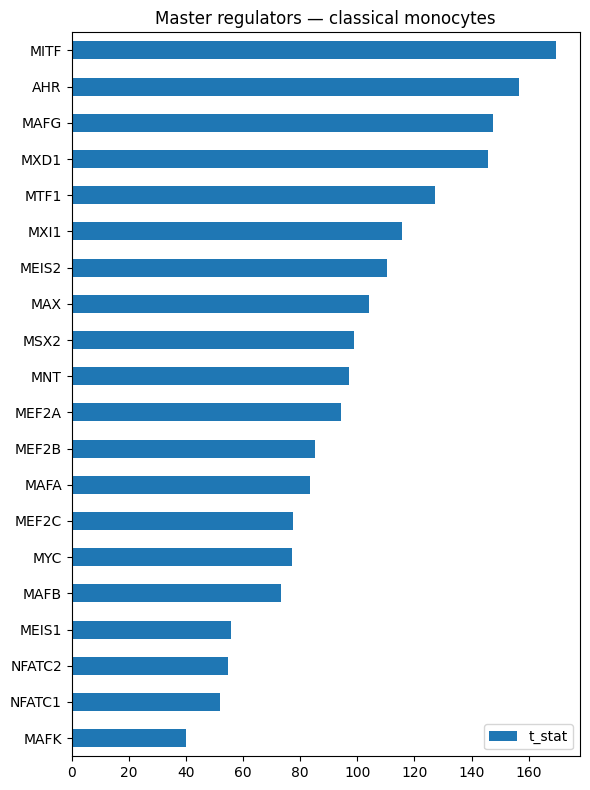

In [71]:
import matplotlib.pyplot as plt

top_TFs.sort_values('t_stat').plot(
    y='t_stat', kind='barh', figsize=(6,8),
    title=f"Master regulators — {celltype}"
)
plt.tight_layout()
#plt.savefig(outdir + 'master_regulators_classical_monocytes.png', dpi=150)

In [72]:
# for all celltypes, get top TFs per celltype
summary = {}
results_all = master_regulator(TF_activity, adata_RNA, celltype='all')
for ct in celltypes:
    # filter significant only
    sig = results_all[results_all[f'{ct}_adj_p'] < 0.05]
    if len(sig) > 0:
        best = sig.sort_values(f'{ct}_t_stat', ascending=False).iloc[0]
        summary[ct] = {'top_TF': best.name, 
                       't_stat': best[f'{ct}_t_stat'],
                       'adj_p':  best[f'{ct}_adj_p']}

summary_df = pd.DataFrame(summary).T
summary_df

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.


,top_TF,t_stat,adj_p
naive CD8 T cells,VSX2,54.411773,0.0
classical monocytes,MITF,169.485392,0.0
naive B cells,BHLHE41,68.962906,0.0
intermediate monocytes,EGR2,48.653978,0.0
naive CD4 T cells,ATF7,61.663887,0.0
memory CD4 T cells,MAF,70.04901,0.0
non-classical monocytes,BATF3,87.238612,0.0
MAIT T cells,GATA6,13.452242,0.0
CD56 (bright) NK cells,TBX21,91.08087,0.0
CD56 (dim) NK cells,SOX13,45.526622,0.0


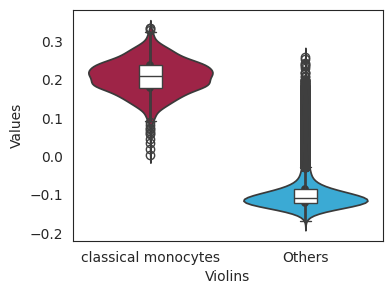

In [76]:
# compare MITF activity in monocytes vs all others
# since MITF seems to be a master regulator in monocytes cells
box_comp('MITF', adata_RNA, 
         celltype1='classical monocytes', celltype2='Others',
         datatype='activity', 
         regulon_score=TF_activity, 
         save=False, outdir=outdir)

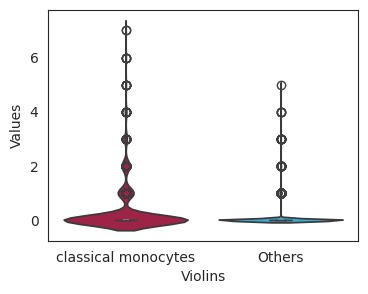

In [79]:
# compare expression instead of activity
box_comp('MITF', adata_RNA,
         celltype1='classical monocytes', celltype2='Others', 
         datatype='expression',
         regulon_score=TF_activity,  # still needed even for expression
         save=False, outdir=outdir)

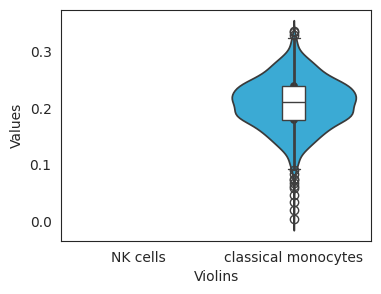

In [87]:
# compare activity for two specific cell types
box_comp('MITF', adata_RNA,
         celltype1='NK cells', celltype2='classical monocytes',
         datatype='activity',
         regulon_score=TF_activity,
         save=False, outdir=outdir)

### 1. TF expression 
= how much the TF gene itself is transcribed in a cell
``` python
RNA.loc['MAFB', 'cell_001']  = 3.2  ← MAFB mRNA counts in that cell
``` 



In [94]:
adata_RNA.X.shape    # cells x genes

(9543, 25485)

In [102]:
adata_RNA.X[0, 65]   # scRNA-seq counts of gene 65 in cell 0

4.0

### 2. TF Activity
= how much the TF's target genes are expressed in a cell, weighted by the GRN.

A TF can be expressed but inactive 

```python
TF_activity.loc['MAFB', 'cell_001'] = 156.7  ← MAFB's regulon is highly active
```

Inferred indirectly — MAFB is "active" if the genes it regulates (according to your trained LINGER GRN) are highly expressed in that cell, above what you'd expect by chance.

```
MAFB expression:  moderate (present in many cell types)
MAFB activity:    very high (its target genes are specifically 
                  upregulated in monocytes above all other cells)
```

This is why activity is more informative than expression for identifying master regulators — it captures the functional impact of the TF on the transcriptome rather than just its presence.